# 06 — So sánh các mô hình/kiến trúc khác nhau
Nguyễn Minh Vinh · B23DCCN934.

Notebook bổ sung theo hướng bài Phạm Văn Tư. Dataset giữ nguyên: CDC và giá nhà; MNIST và EuroSAT; AAPL và Online Retail II.

- ML: Logistic Regression/Ridge, Random Forest, MLP.
- CNN: CNN cơ bản, VGG-style, MobileNet-style, ResNet-style.
- RNN: Simple RNN, LSTM, GRU, BiLSTM.

Notebook 02–04 đã có scratch/Keras/PyTorch cho kiến trúc cơ sở. Notebook này so sánh **kiến trúc khác nhau**, CNN/RNN được train từ đầu bằng PyTorch. Các bản “style” là mạng nhỏ 16×16, không phải VGG-11/MobileNetV2/ResNet-18 đầy đủ hoặc pretrained.

Chạy tuần tự từ trên xuống. `RETRAIN=False` đọc checkpoint đã train và tạo lại bảng/hình; đổi thành `True` để train lại toàn bộ. Mỗi lần huấn luyện mới sẽ ghi đè kết quả kiến trúc tương ứng.

In [1]:
import os,sys,json
from pathlib import Path
os.environ['OPENBLAS_NUM_THREADS']='2'
os.environ['OMP_NUM_THREADS']='2'
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/architectures.py').exists())
sys.path.insert(0,str(ROOT/'src'))
sys.path.insert(0,str(ROOT/'tools'))
from IPython.display import display,Image,Code
import pandas as pd
RETRAIN=False

## 1. Các kiến trúc CNN và RNN
CNN dùng tensor NHWC đầu vào, chuyển NCHW khi tích chập. VGG-style tăng độ sâu bằng kernel 3×3; MobileNet-style tách depthwise và pointwise, có nhánh mở rộng/chiếu tuyến tính; ResNet-style cộng nhánh tắt.

RNN/LSTM/GRU dùng hidden size 32. BiLSTM nối trạng thái cuối hai chiều của **cửa sổ lịch sử đã quan sát**, không đọc ngày/tuần chứa target. BiLSTM nhiều tham số hơn nên phép so sánh không phải cùng số tham số.

In [2]:
"""Small, train-from-scratch architecture comparisons for the existing datasets.

VGG/MobileNet/ResNet-style networks illustrate architectural mechanisms. They
are deliberately reduced for 16x16 inputs, not full named ImageNet networks.
"""
import torch
from torch import nn

CNN_NAMES = ['basic_cnn', 'vgg_style', 'mobilenet_style', 'resnet_style']
RNN_NAMES = ['simple_rnn', 'lstm', 'gru', 'bilstm']
LABELS = dict(basic_cnn='CNN cơ bản', vgg_style='VGG-style',
              mobilenet_style='MobileNet-style', resnet_style='ResNet-style',
              simple_rnn='Simple RNN', lstm='LSTM', gru='GRU', bilstm='BiLSTM')

def cnn_spec(name, channels, outputs=10):
    def conv(key, a, b, k=3, pad=1, groups=1):
        return dict(op='conv', name=key, inputs=a, outputs=b, kernel=k, padding=pad, groups=groups)
    def dense(key, a, b): return dict(op='linear', name=key, inputs=a, outputs=b)
    relu=dict(op='relu'); pool=dict(op='pool')
    if name == 'basic_cnn':
        return [conv('conv', channels, 8, pad=0), relu, pool,
                dict(op='flatten'), dense('head', 8*7*7, outputs)]
    if name == 'vgg_style':
        return [conv('c1', channels, 16), relu, conv('c2', 16, 16), relu, pool,
                conv('c3', 16, 32), relu, conv('c4', 32, 32), relu, pool,
                dict(op='flatten'), dense('fc', 32*4*4, 64), relu, dense('head', 64, outputs)]
    if name == 'mobilenet_style':
        return [conv('stem', channels, 16), relu, dict(op='save'),
                conv('expand1', 16, 32, 1, 0), relu,
                conv('depth1', 32, 32, groups=32), relu,
                conv('project1', 32, 16, 1, 0), dict(op='add'), pool,
                conv('expand2', 16, 48, 1, 0), relu,
                conv('depth2', 48, 48, groups=48), relu,
                conv('project2', 48, 24, 1, 0), dict(op='gap'), dense('head', 24, outputs)]
    if name == 'resnet_style':
        return [conv('stem', channels, 16), relu, dict(op='save'),
                conv('r1a', 16, 16), relu, conv('r1b', 16, 16), dict(op='add'), relu, pool,
                conv('transition', 16, 32, 1, 0), dict(op='save'),
                conv('r2a', 32, 32), relu, conv('r2b', 32, 32), dict(op='add'), relu,
                dict(op='gap'), dense('head', 32, outputs)]
    raise ValueError(name)

class CNN(nn.Module):
    def __init__(self, spec):
        super().__init__(); self.spec=spec; self.layers=nn.ModuleDict()
        for s in spec:
            if s['op']=='conv':
                self.layers[s['name']]=nn.Conv2d(s['inputs'],s['outputs'],s['kernel'],
                                                padding=s['padding'],groups=s['groups'])
            elif s['op']=='linear':self.layers[s['name']]=nn.Linear(s['inputs'],s['outputs'])
    def forward(self, x):
        x=x.permute(0,3,1,2); residual=None
        for s in self.spec:
            op=s['op']
            if op in ['conv','linear']:x=self.layers[s['name']](x)
            elif op=='relu':x=torch.relu(x)
            elif op=='pool':x=nn.functional.avg_pool2d(x,2)
            elif op=='flatten':x=x.flatten(1)
            elif op=='gap':x=x.mean((2,3))
            elif op=='save':residual=x
            elif op=='add':x=x+residual
        return x

class Recurrent(nn.Module):
    def __init__(self, name, inputs, outputs, hidden=32):
        super().__init__(); self.name=name
        layer={'simple_rnn':nn.RNN,'lstm':nn.LSTM,'gru':nn.GRU,'bilstm':nn.LSTM}[name]
        self.rnn=layer(inputs,hidden,batch_first=True,bidirectional=name=='bilstm')
        self.head=nn.Linear(hidden*(2 if name=='bilstm' else 1),outputs)
    def forward(self,x):
        _, state=self.rnn(x)
        h=state[0] if isinstance(state,tuple) else state
        h=torch.cat((h[-2],h[-1]),dim=1) if self.name=='bilstm' else h[-1]
        return self.head(h)

def build(name, shape, outputs):
    return CNN(cnn_spec(name,shape[-1],outputs)) if name in CNN_NAMES else Recurrent(name,shape[-1],outputs)


## 2. Quy trình huấn luyện có kiểm soát
Cùng split và thống kê train của notebook trước; không tạo lại tập test. Bốn kiến trúc trong cùng bài dùng Adam lr=0,001, batch=128, 20 epoch, seed=42 và clip norm=1. Class weights chỉ tính từ train. Checkpoint chọn bằng validation loss, kiến trúc chọn bằng validation Macro-F1/RMSE. Không chọn theo test.

Không diễn giải khác biệt giữa nhóm Adam mới và nhóm SGD cũ chỉ là tác dụng của kiến trúc. Thời gian CPU phụ thuộc máy; không bịa FLOPs/FPS. Một seed chưa cho phép kết luận thống kê.

In [3]:
"""Run controlled comparisons across architectures, separate from framework parity."""
import os
os.environ.setdefault('OMP_NUM_THREADS','2')
os.environ.setdefault('OPENBLAS_NUM_THREADS','2')
from pathlib import Path
import sys,json,time,copy
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from experiment import load,metrics,restore_target
from architecture_inference import predict_arch
torch.set_num_threads(2)

def run(key,name,epochs=20):
    torch.manual_seed(42);np.random.seed(42)
    d=load(key);meta=d['meta'];task=meta['task'];tr,va,te=[d[s] for s in ['train','val','test']]
    out=ROOT/'results/architectures'/key;out.mkdir(parents=True,exist_ok=True)
    outputs=len(meta['classes']) if task=='classification' else 1
    config=dict(name=name,label=LABELS[name],kind=meta['kind'],shape=list(d['x'].shape[1:]),outputs=outputs,hidden=32)
    if meta['kind']=='cnn':config['spec']=cnn_spec(name,d['x'].shape[-1],outputs)
    model=build(name,d['x'].shape[1:],outputs);optimizer=torch.optim.Adam(model.parameters(),lr=.001)
    x=torch.tensor(d['x'],dtype=torch.float32)
    y=torch.tensor(d['y'],dtype=torch.long if task=='classification' else torch.float32)
    weights=None
    if task=='classification':weights=torch.tensor(len(tr)/(outputs*np.bincount(d['y'][tr].astype(int),minlength=outputs)),dtype=torch.float32)
    def loss_fn(z,target):
        return ((z[:,0]-target)**2).mean() if task=='regression' else (torch.nn.functional.cross_entropy(z,target,reduction='none')*weights[target]).mean()
    def predict(ix):
        model.eval()
        with torch.no_grad():return torch.cat([model(x[chunk]) for chunk in np.array_split(ix,max(1,int(np.ceil(len(ix)/256))))]).numpy()
    best=np.inf;best_state=None;history=[];start=time.perf_counter()
    for epoch in range(1,epochs+1):
        model.train();order=np.random.default_rng(42+epoch).permutation(tr);total=0
        for i in range(0,len(order),128):
            ix=order[i:i+128];optimizer.zero_grad();loss=loss_fn(model(x[ix]),y[ix]);loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1);optimizer.step();total+=float(loss.detach())*len(ix)
        z=predict(va);vl=float(loss_fn(torch.tensor(z),y[va]))
        history.append(dict(epoch=epoch,train_loss=total/len(tr),val_loss=vl))
        if vl<best:best=vl;best_state=copy.deepcopy(model.state_dict());best_epoch=epoch
        print(key,name,epoch,round(vl,6),flush=True)
    seconds=time.perf_counter()-start;model.load_state_dict(best_state);model.eval()
    val=predict(va);test=predict(te);p={k:v.detach().numpy().copy() for k,v in best_state.items()}
    native=predict(te[:16]);portable=predict_arch(p,config,d['x'][te[:16]])
    np.testing.assert_allclose(portable,native,atol=3e-5,rtol=3e-5)
    torch.save(best_state,out/f'{name}.pth');np.savez_compressed(out/f'{name}.npz',**p)
    np.savez_compressed(out/f'{name}_predictions.npz',indices=te,logits=test)
    (out/f'{name}_config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2),encoding='utf-8')
    pd.DataFrame(history).to_csv(out/f'{name}_history.csv',index=False)
    row=dict(name=name,label=LABELS[name],seed=42,epochs=epochs,best_epoch=best_epoch,optimizer='Adam',lr=.001,batch=128,
             parameters=sum(v.numel() for v in model.parameters()),seconds=seconds,validation=metrics(d,va,val),test=metrics(d,te,test),
             numpy_max_error=float(abs(native-portable).max()))
    (out/f'{name}.json').write_text(json.dumps(row,ensure_ascii=False,indent=2),encoding='utf-8')
    return row

def summarize(key):
    d=load(key);out=ROOT/'results/architectures'/key;names=CNN_NAMES if d['meta']['kind']=='cnn' else RNN_NAMES
    rows=[json.loads((out/f'{n}.json').read_text(encoding='utf-8')) for n in names]
    criterion='RMSE' if d['meta']['task']=='regression' else 'MacroF1'
    chosen=min(rows,key=lambda r:r['validation'][criterion]) if criterion=='RMSE' else max(rows,key=lambda r:r['validation'][criterion])
    (out/'selection.json').write_text(json.dumps(dict(name=chosen['name'],criterion=criterion,split='validation'),indent=2))
    table=pd.DataFrame([dict(Model=r['name'],**r['test'],Parameters=r['parameters'],TrainSeconds=r['seconds'],BestEpoch=r['best_epoch']) for r in rows]);table.to_csv(out/'comparison.csv',index=False)
    fig,axs=plt.subplots(2,2,figsize=(10,6))
    for ax,n in zip(axs.flat,names):
        h=pd.read_csv(out/f'{n}_history.csv');ax.plot(h.epoch,h.train_loss,label='train');ax.plot(h.epoch,h.val_loss,label='validation');ax.set_title(n);ax.legend()
    fig.tight_layout();fig.savefig(out/'learning.png',dpi=140);plt.close(fig)
    fig,ax=plt.subplots(figsize=(8,3));ax.bar(table.Model,table[criterion]);ax.set_ylabel('Test '+criterion);ax.set_title(key+' / identical split, Adam 0.001, 20 epochs');fig.tight_layout();fig.savefig(out/'comparison.png',dpi=140);plt.close(fig)
    actual=d['actual_close'][d['test']] if key=='stock' else d['y'][d['test']]
    z=np.load(out/f"{chosen['name']}_predictions.npz")['logits']
    if key=='stock':
        pred=restore_target(d,d['test'],z);indices=np.argsort(abs(pred-actual))[-6:][::-1]
    else:pred=z.argmax(1);indices=np.flatnonzero(pred!=actual)[:6]
    (out/'errors.json').write_text(json.dumps([dict(index=int(d['test'][i]),actual=float(actual[i]),prediction=float(pred[i])) for i in indices],indent=2))
    return table


## 3. ML: ba họ thuật toán trên cùng dữ liệu
Đọc kết quả Logistic Regression/Ridge và Random Forest đã train cùng split với MLP. MLP đại diện dùng checkpoint PyTorch của phép đối chiếu thư viện. Đây là ba thuật toán khác nhau; không tính ba framework thành ba thuật toán. Code fit và xuất checkpoint bên dưới.

In [4]:
display(Code(filename=str(ROOT/'tools/baselines.py'),language='python'))

from pathlib import Path
import sys,json,time,joblib
import numpy as np
import pandas as pd
ROOT=Path(__file__).resolve().parents[1];sys.path.insert(0,str(ROOT/'src'))
from experiment import load,metrics
from sklearn.linear_model import LogisticRegression,Ridge
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
for key in ['diabetes','housing']:
    d=load(key);tr,va,te=d['train'],d['val'],d['test'];rows=[]
    out=d['out']/'classical';out.mkdir(exist_ok=True)
    models=[('LogisticRegression',LogisticRegression(max_iter=500,class_weight='balanced',random_state=42)),('RandomForest',RandomForestClassifier(n_estimators=100,max_depth=12,class_weight='balanced',random_state=42,n_jobs=2))] if key=='diabetes' else [('Ridge',Ridge(alpha=1)),('RandomForest',RandomForestRegressor(n_estimators=100,max_depth=12,random_state=42,n_jobs=2))]
    for name,model in models:
        start=time.perf_counter();model.fit(d['x'][tr],d['y'][tr]);seconds=time.perf_counter()-start
        pred=np.log(np.maximum(model.predict_proba(d['x'][te]),1e-12)) if key=='diabetes' else model.predict(d['x'][te])[:,None]
        val=np.log(np.maximum(model.predict_proba(d['x'][va]),1e-12)) if key=='diabetes' else model.predict(d['x'][va])[:,None]
        config=dict(name=name,kind='forest' if name=='RandomForest' else 'linear',task=d['meta']['task'])
        if name=='RandomForest':
            params={}
            for i,estimator in enumerate(model.estimators_):
                tree=estimator.tree_;v=tree.value[:,0,:]
                if key=='diabetes':v=v/np.maximum(v.sum(axis=1,keepdims=True),1e-12)
                for field,value in dict(left=tree.children_left,right=tree.children_right,feature=tree.feature,threshold=tree.threshold,value=v).items():params[f'{i}_{field}']=value
            config['trees']=len(model.estimators_)
        else:params=dict(coef=np.atleast_2d(model.coef_),intercept=np.atleast_1d(model.intercept_))
        np.savez_compressed(out/f'{name}.npz',**params);joblib.dump(model,out/f'{name}.joblib')
        np.savez_compressed(out/f'{name}_predictions.npz',indices=te,logits=pred)
        (out/f'{name}_config.json').write_text(json.dumps(config,indent=2))
        (out/f'{name}.json').write_text(json.dumps(dict(name=name,validation=metrics(d,va,val),test=metrics(d,te,pred),seconds=seconds),indent=2))
        rows.append(dict(Model=name,**metrics(d,te,pred)))
    pd.DataFrame(rows).to_csv(d['out']/'classical_baselines.csv',index=False);print(key,rows)

In [5]:
import runpy
if RETRAIN or not (ROOT/'results/diabetes/classical/RandomForest.npz').exists():
    runpy.run_path(str(ROOT/'tools/baselines.py'),run_name='__main__')
for key in ['diabetes','housing']:
    classical=pd.read_csv(ROOT/'results'/key/'classical_baselines.csv')
    mlp=json.loads((ROOT/'results'/key/'pytorch_42.json').read_text())
    result=pd.concat([classical,pd.DataFrame([dict(Model='MLP',**mlp['test'])])],ignore_index=True)
    print(key);display(result.round(5))
    result.to_csv(ROOT/'results'/key/'model_comparison.csv',index=False)

diabetes


,Model,Accuracy,MacroF1,F1,Precision,Recall,AP,ROC_AUC
0,LogisticRegression,0.7146,0.64025,0.47671,0.34984,0.74799,0.43623,0.79945
1,RandomForest,0.7890,0.67312,0.47850,0.41941,0.55696,0.44968,0.80046
2,MLP,0.7056,0.63380,0.47164,0.34272,0.75604,0.44324,0.79666


housing


,Model,RMSE,MAE,R2
0,Ridge,1.94651,1.55503,0.22473
1,RandomForest,1.85418,1.47186,0.29653
2,MLP,1.87596,1.49801,0.27991


## Dataset mnist
Đầu vào và target lấy nguyên cache đã chuẩn hóa. Hiển thị quy mô và protocol trước khi đánh giá.

In [6]:
data=load('mnist')
display(pd.Series(data['meta']))
print('Train/val/test:',*[len(data[s]) for s in ['train','val','test']])

kind                                                       cnn
task                                            classification
classes                         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
raw_rows                                                 70000
mean                                     [0.13107748329639435]
std                                       [0.2632492780685425]
source       https://storage.googleapis.com/tensorflow/tf-k...
protocol     Fixed stratified benchmark subset; MNIST prese...
transform    Resize16 bilinear /255 then train channel mean...
key                                                      mnist
shape                                              [16, 16, 1]
samples                                                  14000
splits             {'train': 10000, 'val': 2000, 'test': 2000}
counts       {'train': [987, 1124, 993, 1022, 974, 904, 986...
dtype: object

Train/val/test: 10000 2000 2000


### basic_cnn
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [7]:
path=ROOT/'results/architectures/mnist/basic_cnn.json'
row=run('mnist','basic_cnn') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                       basic_cnn
label                                                     CNN cơ bản
seed                                                              42
epochs                                                            20
best_epoch                                                        20
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      4010
seconds                                                     5.909653
validation         {'Accuracy': 0.9555, 'MacroF1': 0.955161084075...
test               {'Accuracy': 0.958, 'MacroF1': 0.9577762509112...
numpy_max_error                                             0.000003
dtype: object

### vgg_style
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [8]:
path=ROOT/'results/architectures/mnist/vgg_style.json'
row=run('mnist','vgg_style') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                       vgg_style
label                                                      VGG-style
seed                                                              42
epochs                                                            20
best_epoch                                                        18
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                     49850
seconds                                                    39.287165
validation         {'Accuracy': 0.9775, 'MacroF1': 0.977428320396...
test               {'Accuracy': 0.9775, 'MacroF1': 0.977290029089...
numpy_max_error                                             0.000005
dtype: object

### mobilenet_style
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [9]:
path=ROOT/'results/architectures/mnist/mobilenet_style.json'
row=run('mnist','mobilenet_style') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                 mobilenet_style
label                                                MobileNet-style
seed                                                              42
epochs                                                            20
best_epoch                                                        20
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      4274
seconds                                                    47.717529
validation         {'Accuracy': 0.8695, 'MacroF1': 0.867377725942...
test               {'Accuracy': 0.877, 'MacroF1': 0.8753868449182...
numpy_max_error                                             0.000004
dtype: object

### resnet_style
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [10]:
path=ROOT/'results/architectures/mnist/resnet_style.json'
row=run('mnist','resnet_style') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                    resnet_style
label                                                   ResNet-style
seed                                                              42
epochs                                                            20
best_epoch                                                        19
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                     24170
seconds                                                    55.200243
validation         {'Accuracy': 0.9515, 'MacroF1': 0.951335250290...
test               {'Accuracy': 0.957, 'MacroF1': 0.9566689807070...
numpy_max_error                                             0.000006
dtype: object

### Bảng so sánh, learning curve và lỗi
Đánh giá cùng test; mặc định chọn theo validation. Kiểm tra baseline, đặc biệt AAPL với giá phiên trước.

,Model,Accuracy,MacroF1,Parameters,TrainSeconds,BestEpoch
0,basic_cnn,0.9580,0.95778,4010,5.90965,20
1,vgg_style,0.9775,0.97729,49850,39.28716,18
2,mobilenet_style,0.8770,0.87539,4274,47.71753,20
3,resnet_style,0.9570,0.95667,24170,55.20024,19


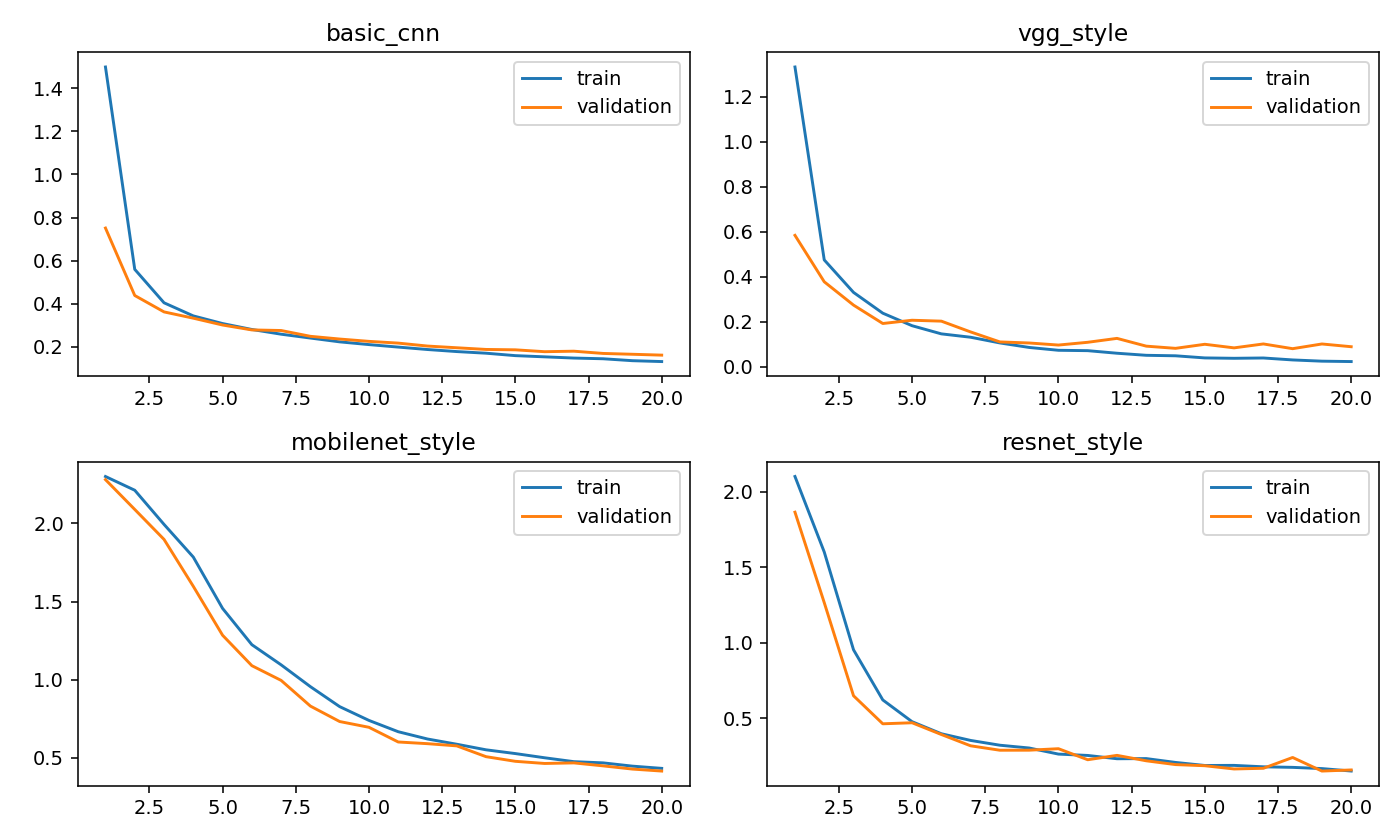

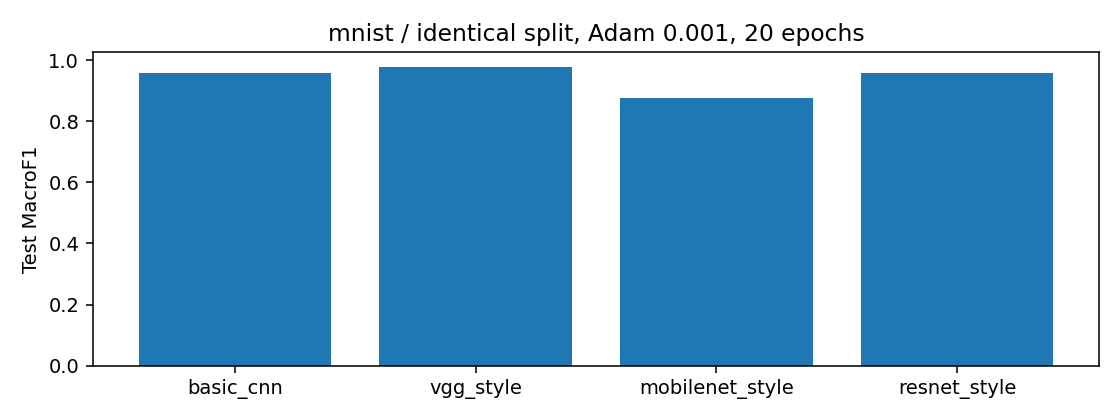

{
  "name": "vgg_style",
  "criterion": "MacroF1",
  "split": "validation"
}
Baseline: {
  "Accuracy": 0.1135,
  "MacroF1": 0.0203861697350696
}


,index,actual,prediction
0,12023,2,7
1,12139,9,8
2,12154,0,8
3,12165,9,7
4,12183,3,7
5,12212,9,2


In [11]:
display(summarize('mnist').round(5))
for file in ['learning.png','comparison.png']:
    display(Image(filename=str(ROOT/'results/architectures/mnist'/file)))
print((ROOT/'results/architectures/mnist/selection.json').read_text())
print('Baseline:',(ROOT/'results/mnist/baseline.json').read_text())
display(pd.read_json(ROOT/'results/architectures/mnist/errors.json'))

## Dataset eurosat
Đầu vào và target lấy nguyên cache đã chuẩn hóa. Hiển thị quy mô và protocol trước khi đánh giá.

In [12]:
data=load('eurosat')
display(pd.Series(data['meta']))
print('Train/val/test:',*[len(data[s]) for s in ['train','val','test']])

kind                                                       cnn
task                                            classification
classes      [AnnualCrop, Forest, HerbaceousVegetation, Hig...
raw_rows                                                 27000
mean         [0.34342673420906067, 0.3801611661911011, 0.40...
std          [0.19104278087615967, 0.12556222081184387, 0.1...
source                      https://zenodo.org/records/7711810
protocol     Fixed stratified benchmark subset; MNIST prese...
transform    Resize16 bilinear /255 then train channel mean...
key                                                    eurosat
shape                                              [16, 16, 3]
samples                                                  10000
splits              {'train': 6400, 'val': 1600, 'test': 2000}
counts       {'train': [711, 711, 711, 593, 593, 474, 593, ...
dtype: object

Train/val/test: 6400 1600 2000


### basic_cnn
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [13]:
path=ROOT/'results/architectures/eurosat/basic_cnn.json'
row=run('eurosat','basic_cnn') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                       basic_cnn
label                                                     CNN cơ bản
seed                                                              42
epochs                                                            20
best_epoch                                                        20
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      4154
seconds                                                     4.102358
validation         {'Accuracy': 0.623125, 'MacroF1': 0.6137798817...
test               {'Accuracy': 0.627, 'MacroF1': 0.6195375136619...
numpy_max_error                                             0.000004
dtype: object

### vgg_style
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [14]:
path=ROOT/'results/architectures/eurosat/vgg_style.json'
row=run('eurosat','vgg_style') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                       vgg_style
label                                                      VGG-style
seed                                                              42
epochs                                                            20
best_epoch                                                        18
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                     50138
seconds                                                    24.312063
validation         {'Accuracy': 0.69125, 'MacroF1': 0.68704827472...
test               {'Accuracy': 0.7065, 'MacroF1': 0.700035496880...
numpy_max_error                                             0.000002
dtype: object

### mobilenet_style
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [15]:
path=ROOT/'results/architectures/eurosat/mobilenet_style.json'
row=run('eurosat','mobilenet_style') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                 mobilenet_style
label                                                MobileNet-style
seed                                                              42
epochs                                                            20
best_epoch                                                        20
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      4562
seconds                                                    28.449694
validation         {'Accuracy': 0.645, 'MacroF1': 0.636690654202426}
test               {'Accuracy': 0.6395, 'MacroF1': 0.627349269535...
numpy_max_error                                             0.000002
dtype: object

### resnet_style
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [16]:
path=ROOT/'results/architectures/eurosat/resnet_style.json'
row=run('eurosat','resnet_style') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                    resnet_style
label                                                   ResNet-style
seed                                                              42
epochs                                                            20
best_epoch                                                        20
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                     24458
seconds                                                     35.02836
validation         {'Accuracy': 0.69125, 'MacroF1': 0.68280256132...
test               {'Accuracy': 0.6915, 'MacroF1': 0.679962541073...
numpy_max_error                                             0.000004
dtype: object

### Bảng so sánh, learning curve và lỗi
Đánh giá cùng test; mặc định chọn theo validation. Kiểm tra baseline, đặc biệt AAPL với giá phiên trước.

,Model,Accuracy,MacroF1,Parameters,TrainSeconds,BestEpoch
0,basic_cnn,0.6270,0.61954,4154,4.10236,20
1,vgg_style,0.7065,0.70004,50138,24.31206,18
2,mobilenet_style,0.6395,0.62735,4562,28.44969,20
3,resnet_style,0.6915,0.67996,24458,35.02836,20


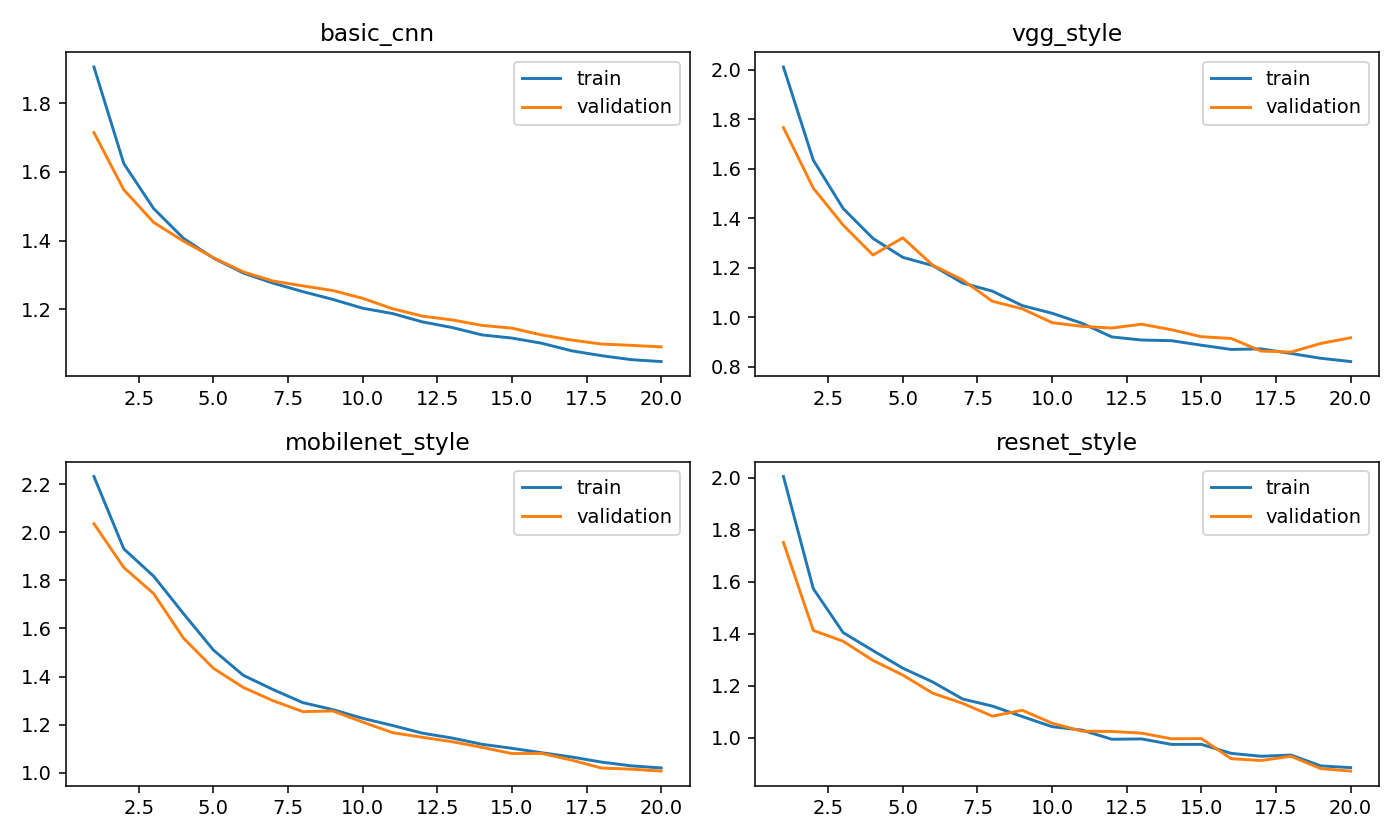

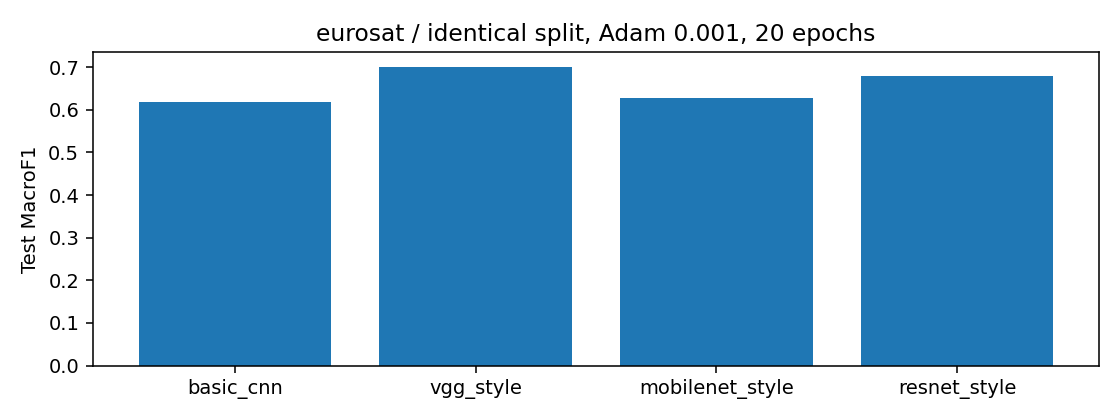

{
  "name": "vgg_style",
  "criterion": "MacroF1",
  "split": "validation"
}
Baseline: {
  "Accuracy": 0.111,
  "MacroF1": 0.01998199819981998
}


,index,actual,prediction
0,8001,3,7
1,8004,0,7
2,8007,3,6
3,8008,2,3
4,8010,3,0
5,8018,6,0


In [17]:
display(summarize('eurosat').round(5))
for file in ['learning.png','comparison.png']:
    display(Image(filename=str(ROOT/'results/architectures/eurosat'/file)))
print((ROOT/'results/architectures/eurosat/selection.json').read_text())
print('Baseline:',(ROOT/'results/eurosat/baseline.json').read_text())
display(pd.read_json(ROOT/'results/architectures/eurosat/errors.json'))

## Dataset stock
Đầu vào và target lấy nguyên cache đã chuẩn hóa. Hiển thị quy mô và protocol trước khi đánh giá.

In [18]:
data=load('stock')
display(pd.Series(data['meta']))
print('Train/val/test:',*[len(data[s]) for s in ['train','val','test']])

kind                                                       rnn
task                                                regression
classes                                [No purchase, Purchase]
raw_rows                                                  2766
source       https://github.com/tuananhtrieu1305/ISD_Assign...
protocol     Chronological 70/15/15 by target date; feature...
transform       Causal OHLCV indicators, train standardization
features     [LogReturn, OpenGap, Range, Body, RelativeMA20...
mean         [0.0008318194886669517, 0.0002356943441554904,...
std          [0.01866917684674263, 0.012287449091672897, 0....
y_mean                                                 0.00076
y_std                                                 0.018754
periods      {'train': ['2015-04-28', '2022-10-12'], 'valid...
details      {'dataset': 'AAPL historical stock', 'raw_rows...
key                                                      stock
shape                                                  

Train/val/test: 1880 403 404


### simple_rnn
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [19]:
path=ROOT/'results/architectures/stock/simple_rnn.json'
row=run('stock','simple_rnn') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                      simple_rnn
label                                                     Simple RNN
seed                                                              42
epochs                                                            20
best_epoch                                                         4
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      1377
seconds                                                     2.759053
validation         {'RMSE': 2.5319386989758885, 'MAE': 1.89726210...
test               {'RMSE': 3.964083750937289, 'MAE': 2.678965715...
numpy_max_error                                                  0.0
dtype: object

### lstm
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [20]:
path=ROOT/'results/architectures/stock/lstm.json'
row=run('stock','lstm') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                            lstm
label                                                           LSTM
seed                                                              42
epochs                                                            20
best_epoch                                                        14
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      5409
seconds                                                     2.753461
validation         {'RMSE': 2.5071341619090086, 'MAE': 1.87746907...
test               {'RMSE': 3.894639123193245, 'MAE': 2.656182218...
numpy_max_error                                                  0.0
dtype: object

### gru
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [21]:
path=ROOT/'results/architectures/stock/gru.json'
row=run('stock','gru') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                             gru
label                                                            GRU
seed                                                              42
epochs                                                            20
best_epoch                                                        18
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      4065
seconds                                                     4.640984
validation         {'RMSE': 2.5113047926337386, 'MAE': 1.87666545...
test               {'RMSE': 3.9381099363136287, 'MAE': 2.67641418...
numpy_max_error                                                  0.0
dtype: object

### bilstm
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [22]:
path=ROOT/'results/architectures/stock/bilstm.json'
row=run('stock','bilstm') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                          bilstm
label                                                         BiLSTM
seed                                                              42
epochs                                                            20
best_epoch                                                         2
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                     10817
seconds                                                     4.472862
validation         {'RMSE': 2.5167928428374653, 'MAE': 1.87225436...
test               {'RMSE': 3.925015805892953, 'MAE': 2.644627749...
numpy_max_error                                                  0.0
dtype: object

### Bảng so sánh, learning curve và lỗi
Đánh giá cùng test; mặc định chọn theo validation. Kiểm tra baseline, đặc biệt AAPL với giá phiên trước.

,Model,RMSE,MAE,R2,Parameters,TrainSeconds,BestEpoch
0,simple_rnn,3.96408,2.67897,0.97017,1377,2.75905,4
1,lstm,3.89464,2.65618,0.97120,5409,2.75346,14
2,gru,3.93811,2.67641,0.97056,4065,4.64098,18
3,bilstm,3.92502,2.64463,0.97075,10817,4.47286,2


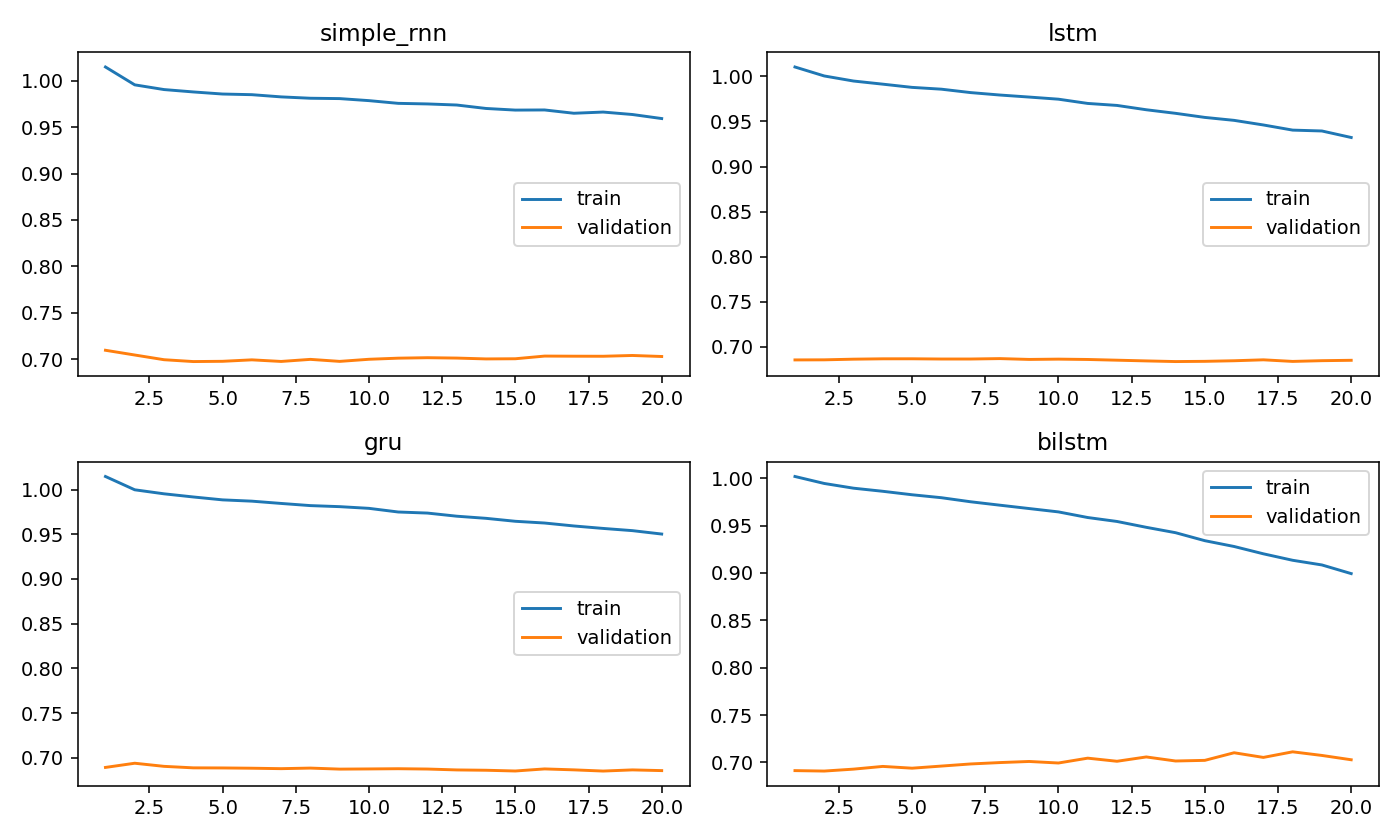

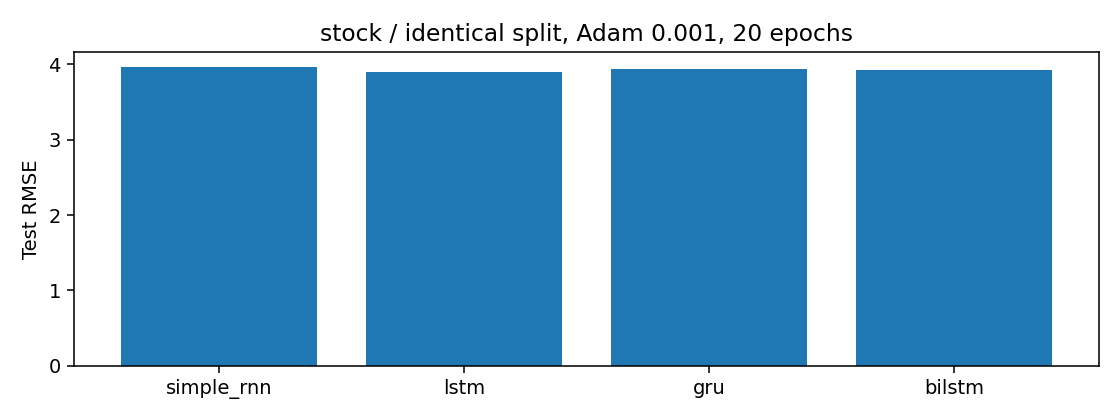

{
  "name": "lstm",
  "criterion": "RMSE",
  "split": "validation"
}
Baseline: {
  "RMSE": 3.904562960342821,
  "MAE": 2.641559260906556,
  "R2": 0.971054924808145
}


,index,actual,prediction
0,2503,198.850006,174.919146
1,2499,203.190002,223.823889
2,2500,188.380005,203.510074
3,2296,207.149994,193.269452
4,2525,210.789993,198.638368
5,2481,227.479996,239.278423


In [23]:
display(summarize('stock').round(5))
for file in ['learning.png','comparison.png']:
    display(Image(filename=str(ROOT/'results/architectures/stock'/file)))
print((ROOT/'results/architectures/stock/selection.json').read_text())
print('Baseline:',(ROOT/'results/stock/baseline.json').read_text())
display(pd.read_json(ROOT/'results/architectures/stock/errors.json'))

## Dataset customer
Đầu vào và target lấy nguyên cache đã chuẩn hóa. Hiển thị quy mô và protocol trước khi đánh giá.

In [24]:
data=load('customer')
display(pd.Series(data['meta']))
print('Train/val/test:',*[len(data[s]) for s in ['train','val','test']])

kind                                                       rnn
task                                            classification
classes                                [No purchase, Purchase]
raw_rows                                               1067371
source       https://github.com/tuananhtrieu1305/ISD_Assign...
protocol     Chronological 70/15/15 by target week; returni...
transform    log1p nonnegative weekly aggregates, then trai...
features     [Orders, Quantity, Revenue, DistinctItems, Act...
mean         [0.13874545693397522, 0.9298350214958191, 1.05...
std          [0.30376744270324707, 2.0236244201660156, 2.26...
y_mean                                                     0.0
y_std                                                      1.0
periods      {'train': ['2010-01-25', '2011-04-18'], 'valid...
details      {'dataset': 'UCI Online Retail II', 'features'...
key                                                   customer
shape                                                  

Train/val/test: 25937 5932 7484


### simple_rnn
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [25]:
path=ROOT/'results/architectures/customer/simple_rnn.json'
row=run('customer','simple_rnn') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                      simple_rnn
label                                                     Simple RNN
seed                                                              42
epochs                                                            20
best_epoch                                                         6
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      1346
seconds                                                    12.174663
validation         {'Accuracy': 0.7501685772083614, 'MacroF1': 0....
test               {'Accuracy': 0.7228754676643506, 'MacroF1': 0....
numpy_max_error                                                  0.0
dtype: object

### lstm
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [26]:
path=ROOT/'results/architectures/customer/lstm.json'
row=run('customer','lstm') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                            lstm
label                                                           LSTM
seed                                                              42
epochs                                                            20
best_epoch                                                         8
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      5186
seconds                                                    16.472836
validation         {'Accuracy': 0.7700606877950101, 'MacroF1': 0....
test               {'Accuracy': 0.7493319080705505, 'MacroF1': 0....
numpy_max_error                                                  0.0
dtype: object

### gru
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [27]:
path=ROOT/'results/architectures/customer/gru.json'
row=run('customer','gru') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                             gru
label                                                            GRU
seed                                                              42
epochs                                                            20
best_epoch                                                        19
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                      3906
seconds                                                    22.010419
validation         {'Accuracy': 0.7697235333782873, 'MacroF1': 0....
test               {'Accuracy': 0.7465259219668626, 'MacroF1': 0....
numpy_max_error                                                  0.0
dtype: object

### bilstm
Nếu RETRAIN=True hoặc thiếu checkpoint, cell huấn luyện từ đầu. Nếu checkpoint đã có, đọc kết quả thực nghiệm đã lưu.

In [28]:
path=ROOT/'results/architectures/customer/bilstm.json'
row=run('customer','bilstm') if RETRAIN or not path.exists() else json.loads(path.read_text(encoding='utf-8'))
display(pd.Series(row))

name                                                          bilstm
label                                                         BiLSTM
seed                                                              42
epochs                                                            20
best_epoch                                                        19
optimizer                                                       Adam
lr                                                             0.001
batch                                                            128
parameters                                                     10370
seconds                                                    27.423835
validation         {'Accuracy': 0.7796695886716116, 'MacroF1': 0....
test               {'Accuracy': 0.7569481560662747, 'MacroF1': 0....
numpy_max_error                                                  0.0
dtype: object

### Bảng so sánh, learning curve và lỗi
Đánh giá cùng test; mặc định chọn theo validation. Kiểm tra baseline, đặc biệt AAPL với giá phiên trước.

,Model,Accuracy,MacroF1,F1,Precision,Recall,AP,ROC_AUC,Parameters,TrainSeconds,BestEpoch
0,simple_rnn,0.72288,0.58631,0.34862,0.25447,0.55334,0.34318,0.70566,1346,12.17466,6
1,lstm,0.74933,0.60519,0.36664,0.27718,0.54138,0.34567,0.70953,5186,16.47284,8
2,gru,0.74653,0.60289,0.36406,0.27424,0.54138,0.34834,0.71199,3906,22.01042,19
3,bilstm,0.75695,0.61071,0.37211,0.28458,0.53739,0.35171,0.71373,10370,27.42383,19


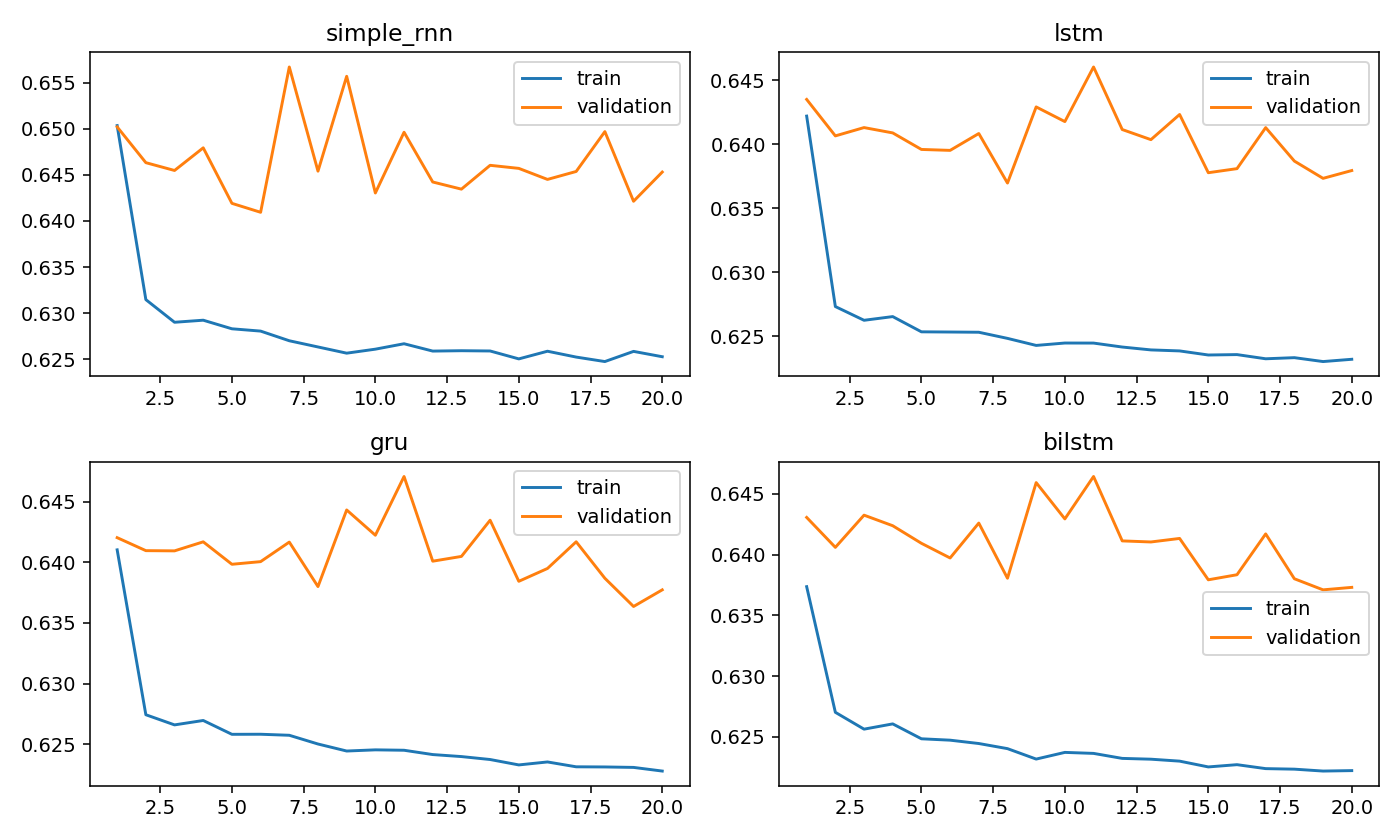

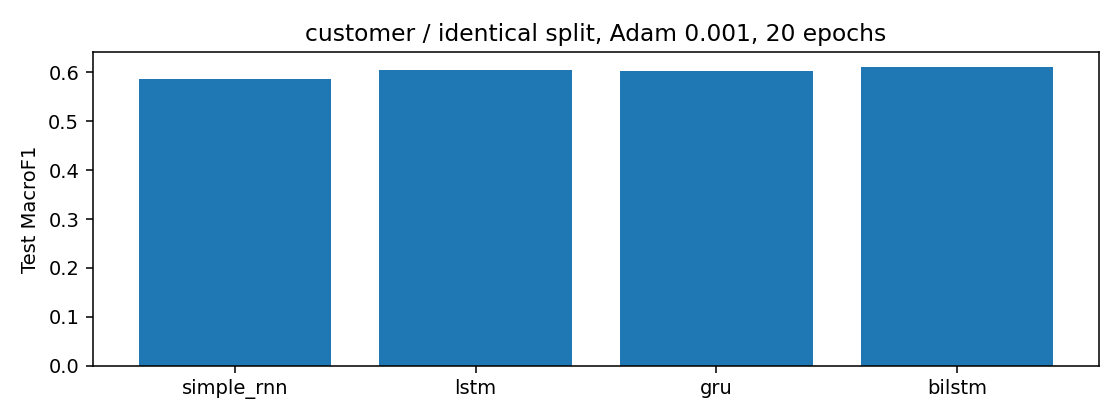

{
  "name": "bilstm",
  "criterion": "MacroF1",
  "split": "validation"
}
Baseline: {
  "Accuracy": 0.8659807589524319,
  "MacroF1": 0.4640887934121017
}


,index,actual,prediction
0,31881,0,1
1,31883,0,1
2,31887,0,1
3,31888,0,1
4,31893,0,1
5,31896,0,1


In [29]:
display(summarize('customer').round(5))
for file in ['learning.png','comparison.png']:
    display(Image(filename=str(ROOT/'results/architectures/customer'/file)))
print((ROOT/'results/architectures/customer/selection.json').read_text())
print('Baseline:',(ROOT/'results/customer/baseline.json').read_text())
display(pd.read_json(ROOT/'results/architectures/customer/errors.json'))

## 4. Đóng gói và kiểm chứng
Web chọn từng kiến trúc thực đã train. NumPy phục vụ trọng số export từ PyTorch, bao gồm đúng thứ tự gate của LSTM/GRU và trạng thái ngược BiLSTM. Đây là **inference NumPy**, không tự nhận đã viết backward scratch cho mọi kiến trúc mới. Scratch training đầy đủ của kiến trúc cơ sở nằm trong notebook 02–04.

Chạy `tools/verify_architectures.py` để nạp lại checkpoint native, so toàn bộ dự đoán test với bản NumPy và kiểm tra API.

In [30]:
display(Code(filename=str(ROOT/'src/architecture_inference.py'),language='python'))

"""NumPy deployment of exported PyTorch architectures (no training dependency)."""
import numpy as np

def sigmoid(x): return 1/(1+np.exp(-np.clip(x,-60,60)))

def conv(x,w,b,padding=0,groups=1):
    if padding:x=np.pad(x,((0,0),(0,0),(padding,padding),(padding,padding)))
    k=w.shape[-1]; patch=np.lib.stride_tricks.sliding_window_view(x,(k,k),axis=(2,3))
    if groups==1:y=np.einsum('nchwij,ocij->nohw',patch,w,optimize=True)
    elif groups==x.shape[1] and w.shape[1]==1:
        y=np.einsum('nchwij,cij->nchw',patch,w[:,0],optimize=True)
    else:raise ValueError('Unsupported convolution groups')
    return y+b[None,:,None,None]

def predict_arch(weights,config,x):
    if config['kind'] in ['linear','forest']:
        if config['kind']=='linear':
            z=x@weights['coef'].T+weights['intercept']
            if config['task']=='regression':return z
            p=sigmoid(z[:,0]);return np.log(np.maximum(np.column_stack((1-p,p)),1e-12))
        values=[]
        for i in range(config['trees']):
            left=weights[f'{i}_left'];right=weights[f'{i}_right'];feature=weights[f'{i}_feature'];threshold=weights[f'{i}_threshold']
            node=np.zeros(len(x),dtype=int)
            while True:
                active=np.flatnonzero(left[node]>=0)
                if not len(active):break
                at=node[active];node[active]=np.where(x[active,feature[at]]<=threshold[at],left[at],right[at])
            values.append(weights[f'{i}_value'][node])
        z=np.mean(values,axis=0)
        return np.log(np.maximum(z,1e-12)) if config['task']=='classification' else z
    if config['kind']=='cnn':
        x=x.transpose(0,3,1,2);residual=None
        for s in config['spec']:
            op=s['op'];prefix='layers.'+s.get('name','')
            if op=='conv':x=conv(x,weights[prefix+'.weight'],weights[prefix+'.bias'],s['padding'],s['groups'])
            elif op=='linear':x=x@weights[prefix+'.weight'].T+weights[prefix+'.bias']
            elif op=='relu':x=np.maximum(x,0)
            elif op=='pool':
                n,c,h,w=x.shape;assert h%2==w%2==0
                x=x.reshape(n,c,h//2,2,w//2,2).mean((3,5))
            elif op=='flatten':x=x.reshape(len(x),-1)
            elif op=='gap':x=x.mean((2,3))
            elif op=='save':residual=x
            elif op=='add':x=x+residual
        return x
    states=[];name=config['name']
    for reverse in ([False,True] if name=='bilstm' else [False]):
        suffix='_reverse' if reverse else ''
        w=weights['rnn.weight_ih_l0'+suffix];u=weights['rnn.weight_hh_l0'+suffix]
        b=weights['rnn.bias_ih_l0'+suffix];c=weights['rnn.bias_hh_l0'+suffix]
        h=np.zeros((len(x),u.shape[1]),dtype=np.float32);cell=np.zeros_like(h)
        for t in (range(x.shape[1]-1,-1,-1) if reverse else range(x.shape[1])):
            a=x[:,t]@w.T+b;v=h@u.T+c
            if name=='simple_rnn':h=np.tanh(a+v)
            elif name in ['lstm','bilstm']:
                i,f,g,o=np.split(a+v,4,axis=1)
                cell=sigmoid(f)*cell+sigmoid(i)*np.tanh(g);h=sigmoid(o)*np.tanh(cell)
            else:
                ar,az,an=np.split(a,3,axis=1);vr,vz,vn=np.split(v,3,axis=1)
                r=sigmoid(ar+vr);z=sigmoid(az+vz);n=np.tanh(an+r*vn);h=(1-z)*n+z*h
        states.append(h)
    h=np.concatenate(states,axis=1)
    return h@weights['head.weight'].T+weights['head.bias']

In [31]:
runpy.run_path(str(ROOT/'tools/bundle_architectures.py'),run_name='__main__')

Bundled 20 additional architecture/classical checkpoints


{'__name__': '__main__',
 '__doc__': 'Extend the existing web bundle without changing the framework-parity models.',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'C:\\DATA\\assignment3\\tieuluan\\tools\\bundle_architectures.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_cla

## 5. Nhận xét và giới hạn
Không thay dataset bằng dữ liệu bài Tư và không sao chép số đo của bài mẫu. So sánh 4 kiến trúc CNN/RNN và 3 họ mô hình ML đáp ứng phần đánh giá mô hình khác nhau; phần ba framework là một phép kiểm tra riêng.

CNN ảnh 16×16, mô hình nhỏ, chưa augmentation/pretrained/spatial split; RNN chỉ một seed và một split thời gian. BiLSTM chỉ nhìn ngược trong cửa sổ quá khứ. Đường học và baseline giúp thấy mô hình lớn hơn có thể không tốt hơn.